# Proyecto Caso de Negocio - Analítica II

### Prdeicción del peso de bebés al nacer

## Carga, selección de variables y exploración de los datos

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [2]:
### Carga de documento, revisión de tipos de datos

df = pd.read_csv('peso_bebes.csv')
df.info()
df.describe(include='all').transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 31 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   source_year             int64  
 1   year                    int64  
 2   month                   int64  
 3   day                     float64
 4   wday                    int64  
 5   state                   float64
 6   is_male                 bool   
 7   child_race              float64
 8   weight_pounds           float64
 9   plurality               int64  
 10  apgar_1min              float64
 11  apgar_5min              float64
 12  mother_residence_state  float64
 13  mother_race             float64
 14  mother_age              int64  
 15  gestation_weeks         float64
 16  lmp                     int64  
 17  mother_married          bool   
 18  mother_birth_state      float64
 19  cigarette_use           object 
 20  cigarettes_per_day      float64
 21  alcohol_use             object 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source_year,"4,255,156.000",NaN,NaN,NaN,"2,022.000",0.000,"2,022.000","2,022.000","2,022.000","2,022.000","2,022.000"
year,"4,255,156.000",NaN,NaN,NaN,"2,022.000",0.000,"2,022.000","2,022.000","2,022.000","2,022.000","2,022.000"
month,"4,255,156.000",NaN,NaN,NaN,6.510,3.426,1.000,4.000,7.000,9.000,12.000
day,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wday,"4,255,156.000",NaN,NaN,NaN,4.047,1.829,1.000,3.000,4.000,6.000,7.000
state,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_male,4255156,2,True,2177227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_race,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight_pounds,"4,250,791.000",NaN,NaN,NaN,7.192,1.305,0.500,6.548,7.275,8.001,18.001
plurality,"4,255,156.000",NaN,NaN,NaN,1.036,0.194,1.000,1.000,1.000,1.000,5.000


In [3]:
# Asegurar que mother_race y father_race sean categóricas
race_cols = ['mother_race', 'father_race']

for col in race_cols:
    if col in df.columns:
        # Si vienen como número, primero las pasamos a string
        if np.issubdtype(df[col].dtype, np.number):
            df[col] = df[col].astype('Int64')  # permite NA
            df[col] = df[col].astype(str)

        # Convertir a tipo categórico
        df[col] = df[col].astype('category')

df.dtypes[['mother_race', 'father_race']]

mother_race    category
father_race    category
dtype: object

In [4]:
### Completitud: Porcentaje de valores faltantes

missing = df.isna().mean().sort_values(ascending=False)  # porcentaje de NA
missing

apgar_1min               1.000
mother_residence_state   1.000
mother_birth_state       1.000
day                      1.000
state                    1.000
drinks_per_week          1.000
child_race               1.000
born_alive_alive         1.000
born_dead                1.000
born_alive_dead          1.000
cigarettes_per_day       0.967
alcohol_use              0.650
cigarette_use            0.650
weight_gain_pounds       0.022
apgar_5min               0.007
ever_born                0.006
gestation_weeks          0.001
weight_pounds            0.001
father_race              0.000
father_age               0.000
source_year              0.000
mother_married           0.000
lmp                      0.000
year                     0.000
mother_age               0.000
mother_race              0.000
plurality                0.000
is_male                  0.000
wday                     0.000
month                    0.000
record_weight            0.000
dtype: float64

### Verificación NaN en uso de cigarrillos y cantidad de cigarrilos

In [5]:
# Filtrar filas donde cigarette_use es NaN
mask_nan_cig_use = df['cigarette_use'].isna()

# Ver 20 ejemplos, incluyendo cigarettes_per_day
df.loc[mask_nan_cig_use, ['cigarette_use', 'cigarettes_per_day']].head(100)

,cigarette_use,cigarettes_per_day
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
135,NaN,NaN
136,NaN,NaN
137,NaN,NaN
138,NaN,NaN


In [6]:
# Filas donde cigarette_use es NaN pero cigarettes_per_day NO es NaN
mask_incons = df['cigarette_use'].isna() & df['cigarettes_per_day'].notna()

# Número de casos con esa inconsistencia
mask_incons.sum()

0

### Eliminación de variables

In [7]:
### Eliminación de variables

cols_drop = [
    'day',
    'state',
    'child_race',
    'apgar_1min',
    'apgar_5min',
    'mother_residence_state',
    'mother_birth_state',
    'drinks_per_week',
    'born_alive_alive',
    'born_alive_dead',
    'born_dead'
]

df = df.drop(columns=cols_drop, errors='ignore')
df.shape, df.columns

((4255156, 20),
 Index(['source_year', 'year', 'month', 'wday', 'is_male', 'weight_pounds',
        'plurality', 'mother_race', 'mother_age', 'gestation_weeks', 'lmp',
        'mother_married', 'cigarette_use', 'cigarettes_per_day', 'alcohol_use',
        'weight_gain_pounds', 'ever_born', 'father_race', 'father_age',
        'record_weight'],
       dtype='object'))

In [8]:
### Eliminación de variables

cols_drop_extra = [
    'source_year',
    'year',
    'month',
    'wday',
    'record_weight',
    'lmp',
    'cigarettes_per_day'
]

df = df.drop(columns=cols_drop_extra, errors='ignore')
df.shape, df.columns

((4255156, 13),
 Index(['is_male', 'weight_pounds', 'plurality', 'mother_race', 'mother_age',
        'gestation_weeks', 'mother_married', 'cigarette_use', 'alcohol_use',
        'weight_gain_pounds', 'ever_born', 'father_race', 'father_age'],
       dtype='object'))

### Feature engineering: variables de riesgo

In [9]:
# ==============================
# Feature engineering: variables de riesgo
# ==============================

# Riesgo por semanas de gestación
df['riesgo_prematuro'] = (df['gestation_weeks'] < 37).astype(int)

# Embarazo múltiple
df['multiplo'] = (df['plurality'] > 1).astype(int)

# Edad de la madre
df['madre_muy_joven'] = (df['mother_age'] < 20).astype(int)
df['madre_mayor']     = (df['mother_age'] >= 35).astype(int)

# Ganancia de peso baja
df['ganancia_baja_peso'] = (df['weight_gain_pounds'] < 15).astype(int)

# Primer hijo
df['primigesta'] = (df['ever_born'] == 1).astype(int)

# Riesgo social simple
df['riesgo_social'] = ((df['mother_married'] == 0) & (df['mother_age'] < 20)).astype(int)


In [10]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 20 columns):
 #   Column              Dtype   
---  ------              -----   
 0   is_male             bool    
 1   weight_pounds       float64 
 2   plurality           int64   
 3   mother_race         category
 4   mother_age          int64   
 5   gestation_weeks     float64 
 6   mother_married      bool    
 7   cigarette_use       object  
 8   alcohol_use         object  
 9   weight_gain_pounds  float64 
 10  ever_born           float64 
 11  father_race         category
 12  father_age          int64   
 13  riesgo_prematuro    int32   
 14  multiplo            int32   
 15  madre_muy_joven     int32   
 16  madre_mayor         int32   
 17  ganancia_baja_peso  int32   
 18  primigesta          int32   
 19  riesgo_social       int32   
dtypes: bool(2), category(2), float64(4), int32(7), int64(3), object(2)
memory usage: 422.0+ MB


((4255156, 20), None)

### Estadísticos

In [11]:
import numpy as np
from scipy.stats import skew, kurtosis

num_vars = df.select_dtypes(include=['int64', 'float64', 'int32']).columns

stats_list = []

for col in num_vars:
    s = df[col].dropna()
    n = s.shape[0]
    mean = s.mean()
    std = s.std()
    se = std / np.sqrt(n) if n > 0 else np.nan
    sk = skew(s, bias=False) if n > 2 else np.nan
    kt = kurtosis(s, fisher=True, bias=False) if n > 3 else np.nan
    cv = std / mean if (mean not in [0, np.nan]) else np.nan
    q1 = s.quantile(0.25)
    median = s.median()          # tendencia central (mediana)
    q3 = s.quantile(0.75)
    min_v = s.min()
    max_v = s.max()
    mode_v = s.mode().iloc[0] if not s.mode().empty else np.nan  # moda

    stats_list.append({
        'variable': col,
        'n': n,
        'mean': mean,
        'std': std,
        'se': se,
        'skew': sk,
        'kurtosis': kt,
        'cv': cv,
        'min': min_v,
        'q1': q1,
        'median': median,
        'q3': q3,
        'max': max_v,
        'mode': mode_v
    })

stats_num_full = pd.DataFrame(stats_list)
stats_num_full

,variable,n,mean,std,se,skew,kurtosis,cv,min,q1,median,q3,max,mode
0,weight_pounds,4250791,7.192,1.305,0.001,-0.904,2.897,0.181,0.500,6.548,7.275,8.001,18.001,7.187
1,plurality,4255156,1.036,0.194,0.000,5.782,37.421,0.188,1.000,1.000,1.000,1.000,5.000,1.000
2,mother_age,4255156,27.412,6.158,0.003,0.248,-0.567,0.225,12.000,23.000,27.000,32.000,50.000,28.000
3,gestation_weeks,4249336,38.570,2.547,0.001,-1.935,9.597,0.066,17.000,38.000,39.000,40.000,47.000,39.000
4,weight_gain_pounds,4160140,35.662,21.383,0.010,1.592,2.607,0.600,1.000,22.000,31.000,42.000,99.000,30.000
5,ever_born,4228549,2.069,1.230,0.001,1.554,3.208,0.595,1.000,1.000,2.000,3.000,8.000,1.000
6,father_age,4255156,40.072,24.617,0.012,1.795,1.672,0.614,10.000,26.000,31.000,38.000,99.000,99.000
7,riesgo_prematuro,4255156,0.123,0.329,0.000,2.295,3.266,2.669,0.000,0.000,0.000,0.000,1.000,0.000
8,multiplo,4255156,0.034,0.182,0.000,5.133,24.353,5.321,0.000,0.000,0.000,0.000,1.000,0.000
9,madre_muy_joven,4255156,0.104,0.305,0.000,2.600,4.762,2.940,0.000,0.000,0.000,0.000,1.000,0.000


In [12]:
num_vars = df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_vars = df.select_dtypes(include=['object', 'bool']).columns.tolist()

num_vars, cat_vars

(['weight_pounds',
  'plurality',
  'mother_age',
  'gestation_weeks',
  'weight_gain_pounds',
  'ever_born',
  'father_age',
  'riesgo_prematuro',
  'multiplo',
  'madre_muy_joven',
  'madre_mayor',
  'ganancia_baja_peso',
  'primigesta',
  'riesgo_social'],
 ['is_male', 'mother_married', 'cigarette_use', 'alcohol_use'])

### Histogramas

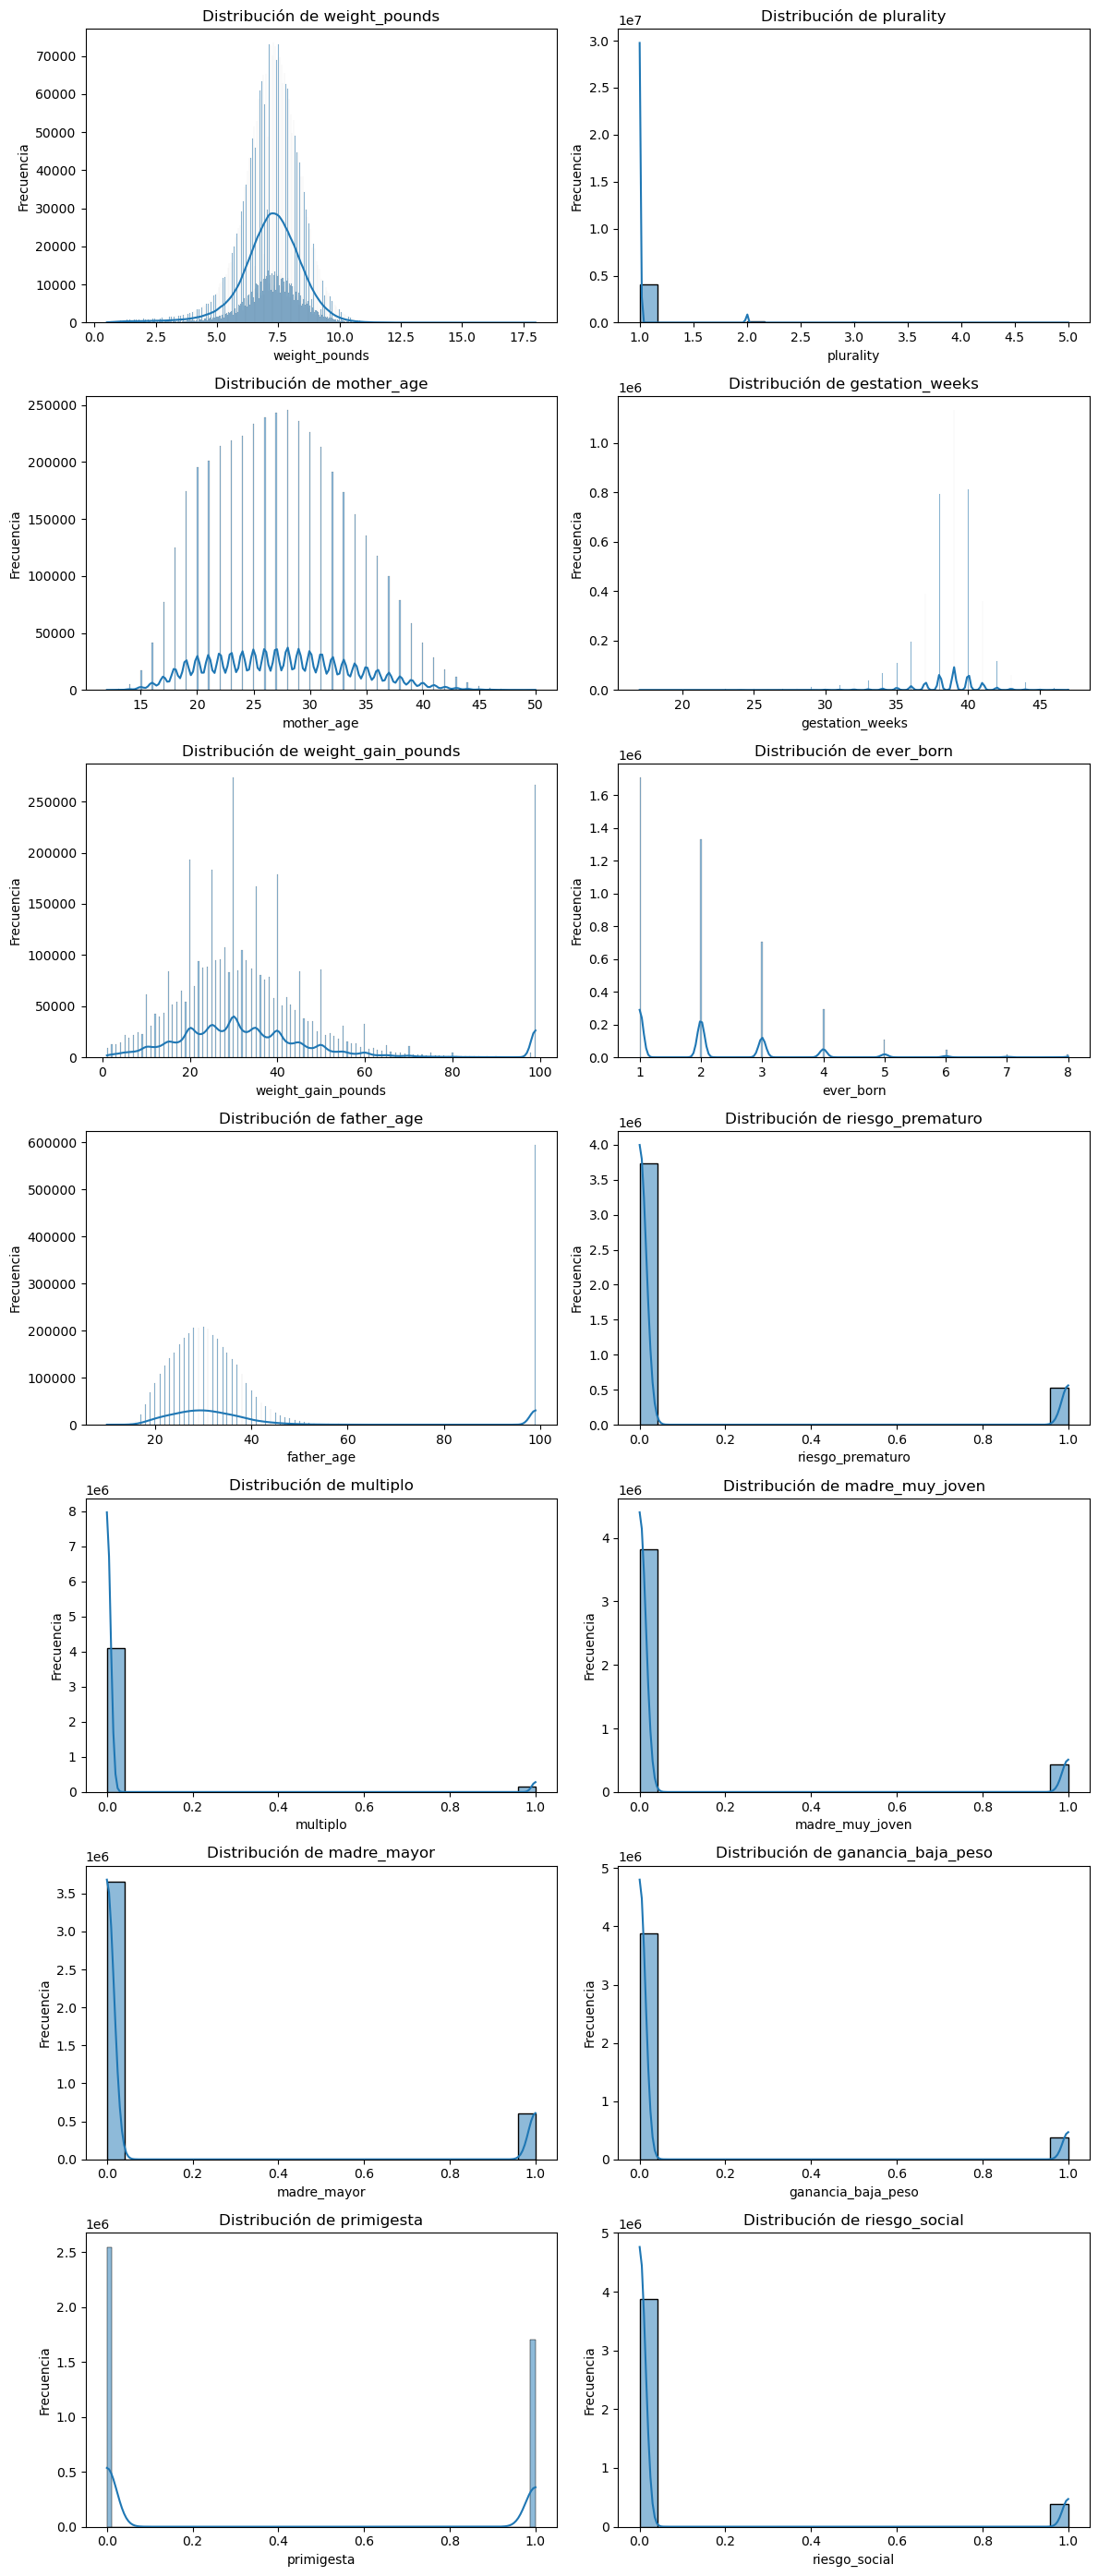

In [13]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

vars_num_all = [v for v in num_vars]  # aquí ya incluye las que no hemos visto

n = len(vars_num_all)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.ravel()

for i, v in enumerate(vars_num_all):
    sns.histplot(df[v].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {v}')
    axes[i].set_xlabel(v)
    axes[i].set_ylabel('Frecuencia')

# Si sobran ejes, los apagamos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots

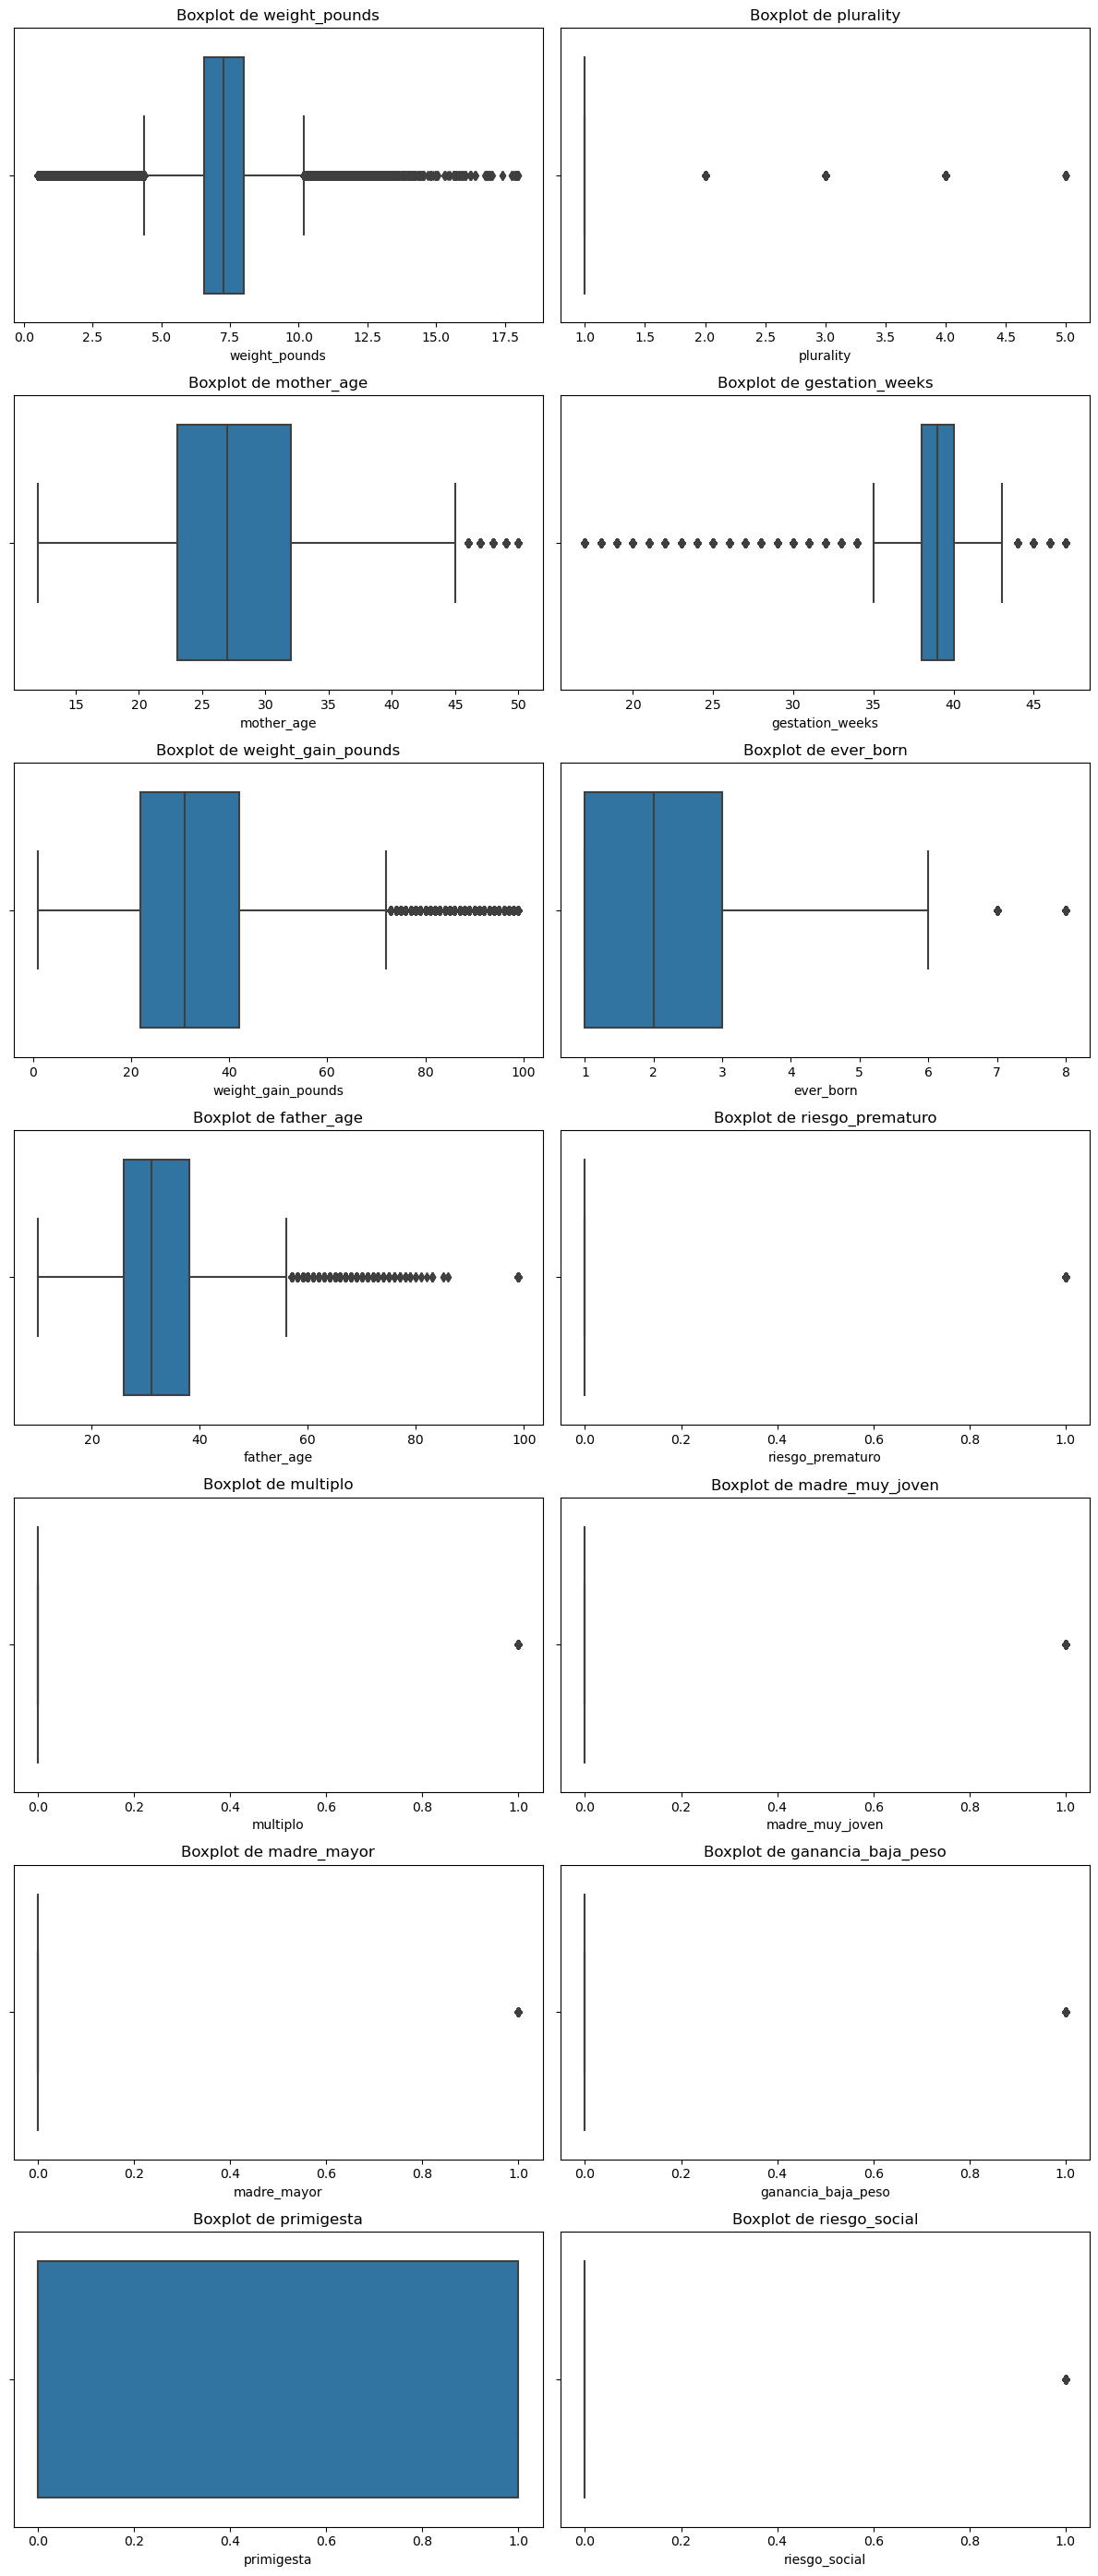

In [14]:
fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.ravel()

for i, v in enumerate(vars_num_all):
    sns.boxplot(x=df[v], ax=axes[i])
    axes[i].set_title(f'Boxplot de {v}')
    axes[i].set_xlabel(v)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribución de Categóricas

In [15]:
for v in cat_vars:
    print(f'\n===== {v} =====')
    print(df[v].value_counts(dropna=False, normalize=True))


===== is_male =====
is_male
True    0.512
False   0.488
Name: proportion, dtype: float64

===== mother_married =====
mother_married
True    0.594
False   0.406
Name: proportion, dtype: float64

===== cigarette_use =====
cigarette_use
NaN     0.650
False   0.316
True    0.033
Name: proportion, dtype: float64

===== alcohol_use =====
alcohol_use
NaN     0.650
False   0.316
True    0.033
Name: proportion, dtype: float64


In [16]:
# Conteo absoluto
mother_race_counts = df['mother_race'].value_counts(dropna=False)

# Proporciones
mother_race_props = df['mother_race'].value_counts(dropna=False, normalize=True)

mother_race_counts, mother_race_props

(mother_race
 <NA>    2912647
 1        993066
 2        262136
 78        23968
 3         22546
 18        12847
 7          8064
 4          7279
 68         5605
 28         2927
 48         1985
 5          1442
 6           562
 38           56
 58           26
 Name: count, dtype: int64,
 mother_race
 <NA>   0.684
 1      0.233
 2      0.062
 78     0.006
 3      0.005
 18     0.003
 7      0.002
 4      0.002
 68     0.001
 28     0.001
 48     0.000
 5      0.000
 6      0.000
 38     0.000
 58     0.000
 Name: proportion, dtype: float64)

In [17]:
# Obtener conteos para el padre
father_race_counts = df['father_race'].value_counts(dropna=False)

# Proporciones (Corregido el nombre de la variable)
father_race_props = df['father_race'].value_counts(dropna=False, normalize=True)

father_race_counts, father_race_props

(father_race
 <NA>    2912647
 1        844036
 99       243138
 2        184801
 78        20466
 3         15441
 18        12785
 4          6266
 7          5475
 68         4517
 28         2515
 48         1664
 5           891
 6           438
 38           55
 58           21
 Name: count, dtype: int64,
 father_race
 <NA>   0.684
 1      0.198
 99     0.057
 2      0.043
 78     0.005
 3      0.004
 18     0.003
 4      0.001
 7      0.001
 68     0.001
 28     0.001
 48     0.000
 5      0.000
 6      0.000
 38     0.000
 58     0.000
 Name: proportion, dtype: float64)

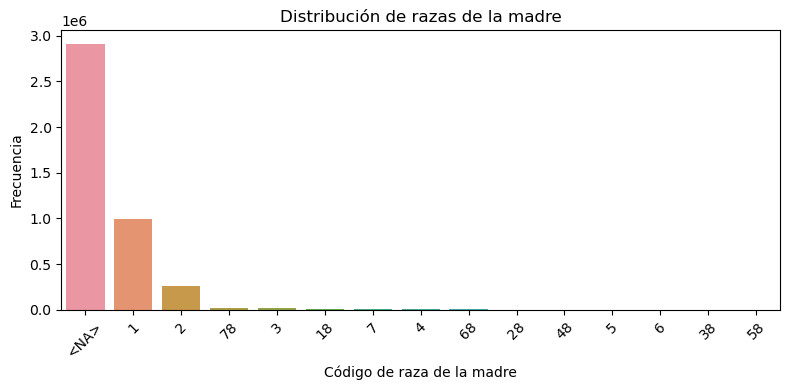

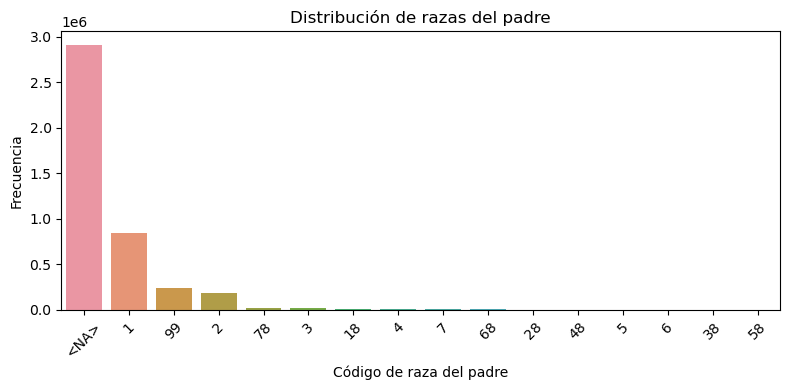

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(x='mother_race', data=df, order=mother_race_counts.index)
plt.title('Distribución de razas de la madre')
plt.xlabel('Código de raza de la madre')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='father_race', data=df, order=father_race_counts.index)
plt.title('Distribución de razas del padre')
plt.xlabel('Código de raza del padre')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Matriz de Correlación

#### Correlación con variables numéricas

In [19]:
target = 'weight_pounds'

# numéricas actuales
num_vars = df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

# por si quedó alguna de control, opcionalmente las excluyes aquí
cols_excluir = []  # agrega aquí algo extra si lo necesitas
num_vars = [c for c in num_vars if c not in cols_excluir]

num_vars

['weight_pounds',
 'plurality',
 'mother_age',
 'gestation_weeks',
 'weight_gain_pounds',
 'ever_born',
 'father_age',
 'riesgo_prematuro',
 'multiplo',
 'madre_muy_joven',
 'madre_mayor',
 'ganancia_baja_peso',
 'primigesta',
 'riesgo_social']

In [20]:
corr_num = df[num_vars].corr()   # por defecto Pearson
corr_num

,weight_pounds,plurality,mother_age,gestation_weeks,weight_gain_pounds,ever_born,father_age,riesgo_prematuro,multiplo,madre_muy_joven,madre_mayor,ganancia_baja_peso,primigesta,riesgo_social
weight_pounds,1.000,-0.307,0.064,0.547,0.076,0.021,-0.080,-0.463,-0.305,-0.062,0.013,-0.090,-0.045,-0.063
plurality,-0.307,1.000,0.074,-0.260,0.057,0.065,0.005,0.276,0.977,-0.034,0.052,-0.018,-0.062,-0.032
mother_age,0.064,0.074,1.000,-0.039,-0.032,0.342,-0.032,0.007,0.073,-0.528,0.668,0.008,-0.309,-0.492
gestation_weeks,0.547,-0.260,-0.039,1.000,0.023,-0.063,-0.049,-0.708,-0.255,-0.000,-0.045,-0.066,0.059,-0.003
weight_gain_pounds,0.076,0.057,-0.032,0.023,1.000,-0.052,0.011,-0.013,0.057,0.026,-0.018,-0.389,0.064,0.025
ever_born,0.021,0.065,0.342,-0.063,-0.052,1.000,0.072,0.044,0.065,-0.235,0.203,0.078,-0.715,-0.221
father_age,-0.080,0.005,-0.032,-0.049,0.011,0.072,1.000,0.050,0.006,0.091,0.044,0.029,-0.021,0.129
riesgo_prematuro,-0.463,0.276,0.007,-0.708,-0.013,0.044,0.050,1.000,0.275,0.018,0.025,0.048,-0.022,0.020
multiplo,-0.305,0.977,0.073,-0.255,0.057,0.065,0.006,0.275,1.000,-0.034,0.051,-0.019,-0.063,-0.032
madre_muy_joven,-0.062,-0.034,-0.528,-0.000,0.026,-0.235,0.091,0.018,-0.034,1.000,-0.138,-0.011,0.281,0.925


In [21]:
corr_target = corr_num[target].sort_values(ascending=False)
corr_target

weight_pounds         1.000
gestation_weeks       0.547
weight_gain_pounds    0.076
mother_age            0.064
ever_born             0.021
madre_mayor           0.013
primigesta           -0.045
madre_muy_joven      -0.062
riesgo_social        -0.063
father_age           -0.080
ganancia_baja_peso   -0.090
multiplo             -0.305
plurality            -0.307
riesgo_prematuro     -0.463
Name: weight_pounds, dtype: float64

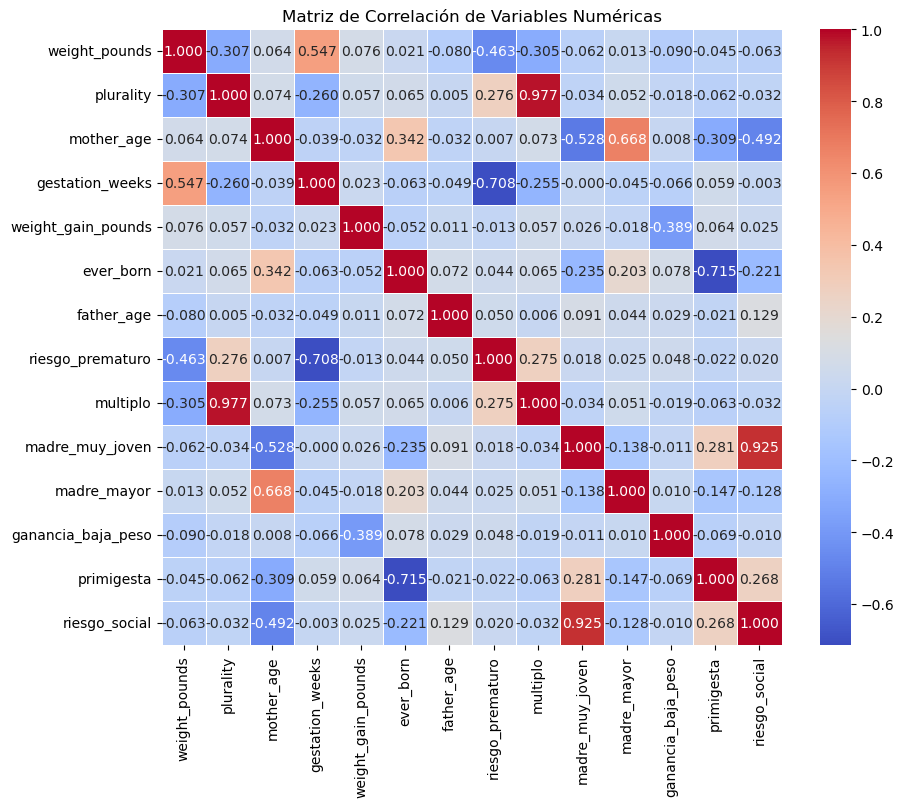

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [23]:
corr_fuerte = corr_target[abs(corr_target) >= 0.1]  # umbral ajustable
corr_fuerte

weight_pounds       1.000
gestation_weeks     0.547
multiplo           -0.305
plurality          -0.307
riesgo_prematuro   -0.463
Name: weight_pounds, dtype: float64

#### Correlación con variables categóricas

In [24]:
import pandas as pd
import numpy as np

target = 'weight_pounds'

# 1. Medias de peso por categoría para todas las categóricas (incluye binarias)
cat_vars = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
cat_summary = {}

for col in cat_vars:
    # agrupa ignorando NaN de la categórica o del target
    tmp = df[[col, target]].dropna()
    if tmp.empty:
        continue
    cat_summary[col] = tmp.groupby(col)[target].agg(['count', 'mean', 'std'])

# Ejemplo: ver resumen para cada categórica
for col, table in cat_summary.items():
    print(f'\n=== {col} vs {target} ===')
    print(table)

# 2. Correlación numérica (punto-biserial) para variables binarias 0/1
#    asumiendo que ya tienes estas como bool o 0/1
binarias = ['is_male', 'mother_married', 'cigarette_use', 'alcohol_use']

corr_bin_target = {}

for col in binarias:
    if col in df.columns:
        s = df[col]
        # convertir a 0/1 si es bool u object
        if s.dtype == 'bool':
            s_num = s.astype(int)
        else:
            # intenta mapear True/False/NaN o 1/0
            s_num = s.map({False:0, True:1, 0:0, 1:1})
        tmp = pd.concat([df[target], s_num], axis=1).dropna()
        if tmp.empty:
            continue
        corr = tmp[target].corr(tmp[col])
        corr_bin_target[col] = corr

print('\nCorrelación (punto-biserial) con peso del bebé:')
for col, c in corr_bin_target.items():
    print(f'{col}: {c:.4f}')


=== is_male vs weight_pounds ===
           count  mean   std
is_male                     
False    2075914 7.067 1.266
True     2174877 7.311 1.330

=== mother_race vs weight_pounds ===
               count  mean   std
mother_race                     
1             992288 7.294 1.281
18             12843 6.870 1.181
2             261856 6.752 1.413
28              2927 7.216 1.088
3              22519 7.304 1.328
38                56 7.508 1.041
4               7277 7.196 1.124
48              1985 6.998 1.094
5               1441 6.999 1.164
58                26 7.141 1.174
6                562 7.187 1.460
68              5604 7.029 1.241
7               8060 7.012 1.239
78             23933 6.981 1.196
<NA>         2909414 7.200 1.296

=== mother_married vs weight_pounds ===
                  count  mean   std
mother_married                     
False           1726610 7.027 1.323
True            2524181 7.304 1.280

=== cigarette_use vs weight_pounds ===
                 count  me

#### ANOVA relación raza de la madre y del padre

In [25]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

target = 'weight_pounds'

# 1. Mapear códigos a etiquetas legibles (si no lo hiciste antes)
race_map = {
    '1': 'White',
    '2': 'Negro',
    '3': 'Indio_americano',
    '4': 'Chino',
    '5': 'Japones',
    '6': 'Hawaiian',
    '7': 'Filipino',
    '9': 'Otro_desconocido',
    '18': 'Indio_asiatico',
    '28': 'Coreano',
    '39': 'Samoan',
    '48': 'Vietnamita'
}

for col in ['mother_race', 'father_race']:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col + '_label'] = df[col].map(race_map).astype('category')

# 2. ANOVA para mother_race
model_mr = smf.ols(f'{target} ~ C(mother_race_label)', data=df).fit()
anova_mr = sm.stats.anova_lm(model_mr, typ=2)
print('ANOVA peso ~ mother_race')
print(anova_mr)

print('\nMedias de peso por mother_race:')
print(df.groupby('mother_race_label')[target].agg(['count', 'mean', 'std']))

# 3. ANOVA para father_race
model_fr = smf.ols(f'{target} ~ C(father_race_label)', data=df).fit()
anova_fr = sm.stats.anova_lm(model_fr, typ=2)
print('\n\nANOVA peso ~ father_race')
print(anova_fr)

print('\nMedias de peso por father_race:')
print(df.groupby('father_race_label')[target].agg(['count', 'mean', 'std']))

ANOVA peso ~ mother_race
                            sum_sq            df         F  PR(>F)
C(mother_race_label)    62,811.572         9.000 4,090.796   0.000
Residual             2,237,894.966 1,311,748.000       NaN     NaN

Medias de peso por mother_race:
                    count  mean   std
mother_race_label                    
Chino                7277 7.196 1.124
Coreano              2927 7.216 1.088
Filipino             8060 7.012 1.239
Hawaiian              562 7.187 1.460
Indio_americano     22519 7.304 1.328
Indio_asiatico      12843 6.870 1.181
Japones              1441 6.999 1.164
Negro              261856 6.752 1.413
Vietnamita           1985 6.998 1.094
White              992288 7.294 1.281


ANOVA peso ~ father_race
                            sum_sq            df         F  PR(>F)
C(father_race_label)    34,389.982         9.000 2,283.863   0.000
Residual             1,796,124.200 1,073,537.000       NaN     NaN

Medias de peso por father_race:
                    coun

## Transformación de variables

### Raza de los padres

In [26]:
# Partimos de las etiquetas legibles que ya creaste
# mother_race_label y father_race_label

rare_threshold = 0.02  # 2 % del total, ajustable

def agrupar_razas(df, col, thr=0.02):
    freqs = df[col].value_counts(normalize=True)
    rares = freqs[freqs < thr].index
    new_col = col + '_grp'

    # Corregir error: Agregar 'Otros' a las categorías existentes antes de asignar
    df[new_col] = df[col].cat.add_categories(['Otros'])
    df[new_col] = df[new_col].where(~df[new_col].isin(rares), other='Otros')

    # Eliminar categorías que ya no se usan (opcional)
    df[new_col] = df[new_col].cat.remove_unused_categories()
    return df, freqs, rares

df, freq_mr, rares_mr = agrupar_razas(df, 'mother_race_label', rare_threshold)
df, freq_fr, rares_fr = agrupar_razas(df, 'father_race_label', rare_threshold)

print('Frecuencias mother_race_label:\n', freq_mr)
print('\nRazas de madre agrupadas como Otros:\n', rares_mr)
print('\nFrecuencias father_race_label:\n', freq_fr)
print('\nRazas de padre agrupadas como Otros:\n', rares_fr)

Frecuencias mother_race_label:
 mother_race_label
White             0.756
Negro             0.200
Indio_americano   0.017
Indio_asiatico    0.010
Filipino          0.006
Chino             0.006
Coreano           0.002
Vietnamita        0.002
Japones           0.001
Hawaiian          0.000
Name: proportion, dtype: float64

Razas de madre agrupadas como Otros:
 CategoricalIndex(['Indio_americano', 'Indio_asiatico', 'Filipino', 'Chino',
                  'Coreano', 'Vietnamita', 'Japones', 'Hawaiian'],
                 categories=['Chino', 'Coreano', 'Filipino', 'Hawaiian', ..., 'Japones', 'Negro', 'Vietnamita', 'White'], ordered=False, dtype='category', name='mother_race_label')

Frecuencias father_race_label:
 father_race_label
White             0.786
Negro             0.172
Indio_americano   0.014
Indio_asiatico    0.012
Chino             0.006
Filipino          0.005
Coreano           0.002
Vietnamita        0.002
Japones           0.001
Hawaiian          0.000
Name: proportion, dtype

In [27]:
# Nueva variable agrupada:
df['mother_race_label_grp'].value_counts(normalize=True)

mother_race_label_grp
White   0.756
Negro   0.200
Otros   0.044
Name: proportion, dtype: float64

In [28]:
df['father_race_label_grp'].value_counts(normalize=True)

father_race_label_grp
White   0.786
Negro   0.172
Otros   0.042
Name: proportion, dtype: float64

In [29]:
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 24 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   is_male                bool    
 1   weight_pounds          float64 
 2   plurality              int64   
 3   mother_race            object  
 4   mother_age             int64   
 5   gestation_weeks        float64 
 6   mother_married         bool    
 7   cigarette_use          object  
 8   alcohol_use            object  
 9   weight_gain_pounds     float64 
 10  ever_born              float64 
 11  father_race            object  
 12  father_age             int64   
 13  riesgo_prematuro       int32   
 14  multiplo               int32   
 15  madre_muy_joven        int32   
 16  madre_mayor            int32   
 17  ganancia_baja_peso     int32   
 18  primigesta             int32   
 19  riesgo_social          int32   
 20  mother_race_label      category
 21  father_race_label      category

In [30]:
df['mother_race'] = df['mother_race_label_grp']
df['father_race'] = df['father_race_label_grp']

df = df.drop(columns=[
    'mother_race_label', 'father_race_label',
    'mother_race_label_grp', 'father_race_label_grp'
], errors='ignore')

In [31]:
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 20 columns):
 #   Column              Dtype   
---  ------              -----   
 0   is_male             bool    
 1   weight_pounds       float64 
 2   plurality           int64   
 3   mother_race         category
 4   mother_age          int64   
 5   gestation_weeks     float64 
 6   mother_married      bool    
 7   cigarette_use       object  
 8   alcohol_use         object  
 9   weight_gain_pounds  float64 
 10  ever_born           float64 
 11  father_race         category
 12  father_age          int64   
 13  riesgo_prematuro    int32   
 14  multiplo            int32   
 15  madre_muy_joven     int32   
 16  madre_mayor         int32   
 17  ganancia_baja_peso  int32   
 18  primigesta          int32   
 19  riesgo_social       int32   
dtypes: bool(2), category(2), float64(4), int32(7), int64(3), object(2)
memory usage: 422.0+ MB


In [32]:
### Completitud: Porcentaje de valores faltantes

missing = df.isna().mean().sort_values(ascending=False)  # porcentaje de NA
missing

father_race          0.748
mother_race          0.691
cigarette_use        0.650
alcohol_use          0.650
weight_gain_pounds   0.022
ever_born            0.006
gestation_weeks      0.001
weight_pounds        0.001
multiplo             0.000
primigesta           0.000
ganancia_baja_peso   0.000
madre_mayor          0.000
madre_muy_joven      0.000
is_male              0.000
riesgo_prematuro     0.000
father_age           0.000
mother_married       0.000
mother_age           0.000
plurality            0.000
riesgo_social        0.000
dtype: float64

### Imputación de datos

In [33]:
import numpy as np
import pandas as pd

# Partimos de df ya cargado y con transformaciones previas

target = 'weight_pounds'

# 1) Eliminar filas sin información en la variable objetivo
df = df.dropna(subset=[target])

# 2) Imputar categoría "Desconocido" en razas de madre y padre
for col in ['mother_race', 'father_race']:
    if col in df.columns:
        # asegurar tipo categoría
        df[col] = df[col].astype('category')
        # añadir categoría y llenar NA
        if 'Desconocido' not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories(['Desconocido'])
        df[col] = df[col].fillna('Desconocido')

# 3) Imputar categoría "Desconocido" en uso de cigarrillos y alcohol
for col in ['cigarette_use', 'alcohol_use']:
    if col in df.columns:
        df[col] = df[col].astype('category')
        if 'Desconocido' not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories(['Desconocido'])
        df[col] = df[col].fillna('Desconocido')

# 4) Imputación por mediana en numéricas con NA bajos
num_impute_median = ['gestation_weeks', 'ever_born', 'weight_gain_pounds']

for col in num_impute_median:
    if col in df.columns:
        med = df[col].median()
        df[col] = df[col].fillna(med)

# 5) Verificación rápida de NA restantes
df.isna().mean().sort_values(ascending=False)

is_male              0.000
weight_pounds        0.000
primigesta           0.000
ganancia_baja_peso   0.000
madre_mayor          0.000
madre_muy_joven      0.000
multiplo             0.000
riesgo_prematuro     0.000
father_age           0.000
father_race          0.000
ever_born            0.000
weight_gain_pounds   0.000
alcohol_use          0.000
cigarette_use        0.000
mother_married       0.000
gestation_weeks      0.000
mother_age           0.000
mother_race          0.000
plurality            0.000
riesgo_social        0.000
dtype: float64

In [34]:
df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4250791 entries, 0 to 4255155
Data columns (total 20 columns):
 #   Column              Dtype   
---  ------              -----   
 0   is_male             bool    
 1   weight_pounds       float64 
 2   plurality           int64   
 3   mother_race         category
 4   mother_age          int64   
 5   gestation_weeks     float64 
 6   mother_married      bool    
 7   cigarette_use       category
 8   alcohol_use         category
 9   weight_gain_pounds  float64 
 10  ever_born           float64 
 11  father_race         category
 12  father_age          int64   
 13  riesgo_prematuro    int32   
 14  multiplo            int32   
 15  madre_muy_joven     int32   
 16  madre_mayor         int32   
 17  ganancia_baja_peso  int32   
 18  primigesta          int32   
 19  riesgo_social       int32   
dtypes: bool(2), category(4), float64(4), int32(7), int64(3)
memory usage: 397.3 MB


### Definir X e Y

##### Celda a ejecutar si no se crearon nuevas variables

In [35]:
# target = 'weight_pounds'

# Lista explícita de features
# num_features = [
  #  'plurality',
  #  'mother_age',
  #  'gestation_weeks',
  #  'weight_gain_pounds',
  #  'ever_born',
  #  'father_age'
#]

#cat_features = [
 #   'is_male',
 #   'mother_married',
 #   'mother_race',
 #   'father_race',
 #   'cigarette_use',
 #   'alcohol_use'
#]

#X = df[num_features + cat_features].copy()
#y = df[target].copy()

##### Celda a ejecutar si sí se crearon nuevas variables

In [36]:
target = 'weight_pounds'

# Lista explícita de features numéricas (incluyendo nuevas variables de riesgo)
num_features = [
    'plurality',
    'mother_age',
    'gestation_weeks',
    'weight_gain_pounds',
    'ever_born',
    'father_age',
    'riesgo_prematuro', # Nuevas variables
    'multiplo',
    'madre_muy_joven',
    'madre_mayor',
    'ganancia_baja_peso',
    'primigesta',
    'riesgo_social'
    # si decidiste crearlas y usarlas:
    # 'riesgo_tabaquismo',
    # 'riesgo_alcohol',
    # 'riesgo_combinado'
]

# Features categóricas (las mismas que ya tenías)
cat_features = [
    'is_male',
    'mother_married',
    'mother_race',
    'father_race',
    'cigarette_use',
    'alcohol_use'
]

X = df[num_features + cat_features].copy()
y = df[target].copy()


### Bool a Category

In [37]:
# Convertir bool a category para que get_dummies los trate igual
for col in ['is_male', 'mother_married']:
    X[col] = X[col].astype('category')

X_dummies = pd.get_dummies(
    X,
    columns=cat_features,
    drop_first=True  # evita colinealidad completa
)

X_dummies.head()
X_dummies.shape

(4250791, 25)

### Definición de Target X e Y

##### Celda a ejecutar si no se crearon nuevas variables

In [38]:
# target = 'weight_pounds'

#num_features = [
#    'plurality',
#    'mother_age',
#    'gestation_weeks',
#    'weight_gain_pounds',
#    'ever_born',
#    'father_age'
#]

#cat_features = [
#    'is_male',
#    'mother_married',
#    'mother_race',
#    'father_race',
#    'cigarette_use',
#    'alcohol_use'
#]

#X = df[num_features + cat_features].copy()
#y = df[target].copy()

# Pasar bool a category y crear dummies
#for col in ['is_male', 'mother_married']:
#    X[col] = X[col].astype('category')

#X_dummies = pd.get_dummies(X, columns=cat_features, drop_first=True)

# Aquí ya NO quedan columnas categóricas redundantes en X_dummies
#X_dummies.info()


##### Celda a ejecutar con la creación de nuevas variables

In [39]:
target = 'weight_pounds'

num_features = [
    'plurality',
    'mother_age',
    'gestation_weeks',
    'weight_gain_pounds',
    'ever_born',
    'father_age',
    'riesgo_prematuro',
    'multiplo',
    'madre_muy_joven',
    'madre_mayor',
    'ganancia_baja_peso',
    'primigesta',
    'riesgo_social'
    # si las usas:
    # 'riesgo_tabaquismo',
    # 'riesgo_alcohol',
    # 'riesgo_combinado'
]

cat_features = [
    'is_male',
    'mother_married',
    'mother_race',
    'father_race',
    'cigarette_use',
    'alcohol_use'
]

X = df[num_features + cat_features].copy()
y = df[target].copy()

# Pasar bool a category y crear dummies
for col in ['is_male', 'mother_married']:
    X[col] = X[col].astype('category')

X_dummies = pd.get_dummies(X, columns=cat_features, drop_first=True)

X_dummies.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4250791 entries, 0 to 4255155
Data columns (total 25 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   plurality                  int64  
 1   mother_age                 int64  
 2   gestation_weeks            float64
 3   weight_gain_pounds         float64
 4   ever_born                  float64
 5   father_age                 int64  
 6   riesgo_prematuro           int32  
 7   multiplo                   int32  
 8   madre_muy_joven            int32  
 9   madre_mayor                int32  
 10  ganancia_baja_peso         int32  
 11  primigesta                 int32  
 12  riesgo_social              int32  
 13  is_male_True               bool   
 14  mother_married_True        bool   
 15  mother_race_White          bool   
 16  mother_race_Otros          bool   
 17  mother_race_Desconocido    bool   
 18  father_race_White          bool   
 19  father_race_Otros          bool   
 20  father_

## Partición de datos

In [40]:
from sklearn.model_selection import train_test_split

y_reg = y
y_clf = (y < 5.5).astype(int)

X_train_temp, X_test, y_reg_train_temp, y_reg_test, y_clf_train_temp, y_clf_test = train_test_split(
    X_dummies, y_reg, y_clf,
    test_size=0.20, random_state=42, stratify=y_clf
)

X_train, X_valid, y_reg_train, y_reg_valid, y_clf_train, y_clf_valid = train_test_split(
    X_train_temp, y_reg_train_temp, y_clf_train_temp,
    test_size=0.25, random_state=42, stratify=y_clf_train_temp
)

In [41]:
# Función auxiliar para resumir cantidad y proporción por conjunto
def resumen_low_weight(nombre, y_clf_subset):
    total = len(y_clf_subset)
    bajo = y_clf_subset.sum()
    prop = bajo / total
    return pd.Series({'total': total, 'bajo_peso': bajo, 'prop_bajo_peso': prop})

res_train = resumen_low_weight('train', y_clf_train)
res_valid = resumen_low_weight('valid', y_clf_valid)
res_test  = resumen_low_weight('test',  y_clf_test)

resumen = pd.DataFrame({
    'train': res_train,
    'valid': res_valid,
    'test':  res_test
}).T

resumen

,total,bajo_peso,prop_bajo_peso
train,"2,550,474.000","201,111.000",0.079
valid,"850,158.000","67,037.000",0.079
test,"850,159.000","67,037.000",0.079


## Desarrollo de los modelos

### Modelo ingenuo con la media del peso

In [42]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Peso promedio en el conjunto de entrenamiento
baseline_mean = y_reg_train.mean()
baseline_median = y_reg_train.median()

print('Media train:', baseline_mean)
print('Mediana train:', baseline_median)

Media train: 7.192357792291169
Mediana train: 7.277459268619999


In [43]:
# Predicciones constantes
y_pred_train_mean  = np.full_like(y_reg_train,  baseline_mean,  dtype=float)
y_pred_valid_mean  = np.full_like(y_reg_valid,  baseline_mean,  dtype=float)
y_pred_test_mean   = np.full_like(y_reg_test,   baseline_mean,  dtype=float)

def eval_reg(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_tr, rmse_tr = eval_reg(y_reg_train, y_pred_train_mean)
mae_va, rmse_va = eval_reg(y_reg_valid, y_pred_valid_mean)
mae_te, rmse_te = eval_reg(y_reg_test,  y_pred_test_mean)

print('Modelo ingenuo (media) - MAE / RMSE')
print(f'Train:  MAE={mae_tr:.3f}, RMSE={rmse_tr:.3f}')
print(f'Valid:  MAE={mae_va:.3f}, RMSE={rmse_va:.3f}')
print(f'Test:   MAE={mae_te:.3f}, RMSE={rmse_te:.3f}')

Modelo ingenuo (media) - MAE / RMSE
Train:  MAE=0.958, RMSE=1.304
Valid:  MAE=0.959, RMSE=1.305
Test:   MAE=0.959, RMSE=1.305


In [44]:
from sklearn.metrics import confusion_matrix, classification_report

# Etiquetas bajo peso reales ya las tenemos: y_clf_train, y_clf_valid, y_clf_test
# Las predicciones ingenuas NO distinguen bajo peso: todos predicen la misma media
# Convertimos la predicción continua en bajo peso / no bajo peso
y_pred_valid_low = (y_pred_valid_mean < 5.5).astype(int)
print('Predicción baja_peso en valid (todos iguales):', np.unique(y_pred_valid_low, return_counts=True))

print('\nMatriz de confusión en valid para el modelo ingenuo:')
print(confusion_matrix(y_clf_valid, y_pred_valid_low))
print('\nReporte de clasificación:')
print(classification_report(y_clf_valid, y_pred_valid_low, digits=3))

Predicción baja_peso en valid (todos iguales): (array([0]), array([850158], dtype=int64))

Matriz de confusión en valid para el modelo ingenuo:
[[783121      0]
 [ 67037      0]]

Reporte de clasificación:


C:\Users\jalfp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0      0.921     1.000     0.959    783121
           1      0.000     0.000     0.000     67037

    accuracy                          0.921    850158
   macro avg      0.461     0.500     0.479    850158
weighted avg      0.849     0.921     0.883    850158



C:\Users\jalfp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jalfp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Regresión

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Entrenar regresión lineal múltiple
linreg = LinearRegression()
linreg.fit(X_train, y_reg_train)

# 2. Predicciones
y_pred_train_lr = linreg.predict(X_train)
y_pred_valid_lr = linreg.predict(X_valid)
y_pred_test_lr  = linreg.predict(X_test)

# 3. Evaluación regresión lineal
def eval_reg(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_tr_lr, rmse_tr_lr = eval_reg(y_reg_train, y_pred_train_lr)
mae_va_lr, rmse_va_lr = eval_reg(y_reg_valid, y_pred_valid_lr)
mae_te_lr, rmse_te_lr = eval_reg(y_reg_test,  y_pred_test_lr)

print('Regresión lineal múltiple - MAE / RMSE')
print(f'Train:  MAE={mae_tr_lr:.3f}, RMSE={rmse_tr_lr:.3f}')
print(f'Valid:  MAE={mae_va_lr:.3f}, RMSE={rmse_va_lr:.3f}')
print(f'Test:   MAE={mae_te_lr:.3f}, RMSE={rmse_te_lr:.3f}')


Regresión lineal múltiple - MAE / RMSE
Train:  MAE=0.798, RMSE=1.031
Valid:  MAE=0.798, RMSE=1.031
Test:   MAE=0.799, RMSE=1.030


In [46]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_valid_low_lr = (y_pred_valid_lr < 5.5).astype(int)

print('\nMatriz de confusión (valid, bajo peso) - Regresión lineal:')
print(confusion_matrix(y_clf_valid, y_pred_valid_low_lr))
print('\nReporte de clasificación:')
print(classification_report(y_clf_valid, y_pred_valid_low_lr, digits=3))



Matriz de confusión (valid, bajo peso) - Regresión lineal:
[[772863  10258]
 [ 39720  27317]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.987     0.969    783121
           1      0.727     0.407     0.522     67037

    accuracy                          0.941    850158
   macro avg      0.839     0.697     0.745    850158
weighted avg      0.933     0.941     0.933    850158



### SVM - LinearSVR - SVR (Support Vector Regression)

##### SVR vs SVC

##### Para clasificación se usa sklearn.svm.SVC (o LinearSVC) y se ajusta directamente a la clase 0/1.

##### Para regresión se usa sklearn.svm.SVR (o LinearSVR), que predice un valor continuo de peso; luego podemos aplicar el umbral 5.5 igual que con la regresión lineal. El valor 5.5 es el referente de bajo peso según la OMS

##### Teniendo en cuenta el tamaño y densidad de la base de datos se plantea crear una muestra estratificada para el uso de los SVR con diferentes Kernel

In [47]:
from sklearn.model_selection import train_test_split

# Etiqueta binaria para estratificar (1 = bajo peso)
y_clf_train = (y_reg_train < 5.5).astype(int)

# Tamaño de muestra para SVR (pensando en usar dos modelos)
n_sample = 50_000   # si ves que aún va lento, baja a 30_000 o 20_000

X_train_s, _, y_reg_train_s, _, y_clf_train_s, _ = train_test_split(
    X_train, y_reg_train, y_clf_train,
    train_size=n_sample,
    random_state=42,
    stratify=y_clf_train
)

# Verificación proporción bajo peso en la muestra
prop_bajo = y_clf_train_s.mean()
print('Tamaño muestra SVR:', X_train_s.shape[0])
print('Proporción bajo peso en muestra:', prop_bajo)

Tamaño muestra SVR: 50000
Proporción bajo peso en muestra: 0.07886


#### SVR con Kernel RBF y grilla reducida

In [48]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def eval_reg(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Pipeline: escalado + SVR
pipe_svr_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid_rbf = {
    'svr__kernel': ['rbf'],
    'svr__C': [1, 10],
    'svr__gamma': ['scale', 0.01],
    'svr__epsilon': [0.1]
}

grid_svr_rbf = GridSearchCV(
    pipe_svr_rbf,
    param_grid=param_grid_rbf,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_svr_rbf.fit(X_train_s, y_reg_train_s)

print('Mejores params SVR RBF:', grid_svr_rbf.best_params_)
best_svr_rbf = grid_svr_rbf.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Mejores params SVR RBF: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


In [49]:
# Supongo que ya tienes:
# best_svr_rbf = grid_svr_rbf.best_estimator_

import numpy as np

def predict_in_batches(model, X, batch_size=20000):
    n = X.shape[0]
    preds = []
    num_batches = int(np.ceil(n / batch_size))
    for i in range(0, n, batch_size):
        batch_idx = i // batch_size + 1
        print(f"Procesando batch {batch_idx}/{num_batches}...")
        X_batch = X[i:i+batch_size]
        preds.append(model.predict(X_batch))
    return np.concatenate(preds, axis=0)

# Predicción en bloques
y_pred_valid_rbf = predict_in_batches(best_svr_rbf, X_valid, batch_size=10000)
y_pred_test_rbf  = predict_in_batches(best_svr_rbf, X_test,  batch_size=10000)

mae_va_rbf, rmse_va_rbf = eval_reg(y_reg_valid, y_pred_valid_rbf)
mae_te_rbf, rmse_te_rbf = eval_reg(y_reg_test,  y_pred_test_rbf)

print(f'SVR RBF - Valid: MAE={mae_va_rbf:.3f}, RMSE={rmse_va_rbf:.3f}')
print(f'SVR RBF - Test:  MAE={mae_te_rbf:.3f}, RMSE={rmse_te_rbf:.3f}')


Procesando batch 1/86...
Procesando batch 2/86...
Procesando batch 3/86...
Procesando batch 4/86...
Procesando batch 5/86...
Procesando batch 6/86...
Procesando batch 7/86...
Procesando batch 8/86...
Procesando batch 9/86...
Procesando batch 10/86...
Procesando batch 11/86...
Procesando batch 12/86...
Procesando batch 13/86...
Procesando batch 14/86...
Procesando batch 15/86...
Procesando batch 16/86...
Procesando batch 17/86...
Procesando batch 18/86...
Procesando batch 19/86...
Procesando batch 20/86...
Procesando batch 21/86...
Procesando batch 22/86...
Procesando batch 23/86...
Procesando batch 24/86...
Procesando batch 25/86...
Procesando batch 26/86...
Procesando batch 27/86...
Procesando batch 28/86...
Procesando batch 29/86...
Procesando batch 30/86...
Procesando batch 31/86...
Procesando batch 32/86...
Procesando batch 33/86...
Procesando batch 34/86...
Procesando batch 35/86...
Procesando batch 36/86...
Procesando batch 37/86...
Procesando batch 38/86...
Procesando batch 39/8

#### SVR con Kernel lineal (grilla un poco más amplia)

In [50]:
pipe_svr_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid_lin = {
    'svr__kernel': ['linear'],
    'svr__C': [1, 10, 100],
    'svr__epsilon': [0.1, 0.2, 0.3]
}

grid_svr_lin = GridSearchCV(
    pipe_svr_lin,
    param_grid=param_grid_lin,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_svr_lin.fit(X_train_s, y_reg_train_s)

print('Mejores params SVR lineal:', grid_svr_lin.best_params_)
best_svr_lin = grid_svr_lin.best_estimator_


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Mejores params SVR lineal: {'svr__C': 10, 'svr__epsilon': 0.3, 'svr__kernel': 'linear'}


In [51]:
# --- EVALUACIÓN EN BLOQUES ---

# VALID
y_pred_valid_lin = predict_in_batches(best_svr_lin, X_valid, batch_size=10000)

# TEST
y_pred_test_lin  = predict_in_batches(best_svr_lin, X_test,  batch_size=10000)

mae_va_lin, rmse_va_lin = eval_reg(y_reg_valid, y_pred_valid_lin)
mae_te_lin, rmse_te_lin = eval_reg(y_reg_test,  y_pred_test_lin)

print(f'SVR lineal - Valid: MAE={mae_va_lin:.3f}, RMSE={rmse_va_lin:.3f}')
print(f'SVR lineal - Test:  MAE={mae_te_lin:.3f}, RMSE={rmse_te_lin:.3f}')


Procesando batch 1/86...
Procesando batch 2/86...
Procesando batch 3/86...
Procesando batch 4/86...
Procesando batch 5/86...
Procesando batch 6/86...
Procesando batch 7/86...
Procesando batch 8/86...
Procesando batch 9/86...
Procesando batch 10/86...
Procesando batch 11/86...
Procesando batch 12/86...
Procesando batch 13/86...
Procesando batch 14/86...
Procesando batch 15/86...
Procesando batch 16/86...
Procesando batch 17/86...
Procesando batch 18/86...
Procesando batch 19/86...
Procesando batch 20/86...
Procesando batch 21/86...
Procesando batch 22/86...
Procesando batch 23/86...
Procesando batch 24/86...
Procesando batch 25/86...
Procesando batch 26/86...
Procesando batch 27/86...
Procesando batch 28/86...
Procesando batch 29/86...
Procesando batch 30/86...
Procesando batch 31/86...
Procesando batch 32/86...
Procesando batch 33/86...
Procesando batch 34/86...
Procesando batch 35/86...
Procesando batch 36/86...
Procesando batch 37/86...
Procesando batch 38/86...
Procesando batch 39/8

#### SVR con kernel polinómico (grilla moderada)

In [52]:
pipe_svr_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid_poly = {
    'svr__kernel': ['poly'],
    'svr__degree': [2, 3],
    'svr__C': [1, 10],
    'svr__gamma': ['scale'],
    'svr__epsilon': [0.1]
}

grid_svr_poly = GridSearchCV(
    pipe_svr_poly,
    param_grid=param_grid_poly,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_svr_poly.fit(X_train_s, y_reg_train_s)

print('Mejores params SVR polinómico:', grid_svr_poly.best_params_)
best_svr_poly = grid_svr_poly.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Mejores params SVR polinómico: {'svr__C': 1, 'svr__degree': 3, 'svr__epsilon': 0.1, 'svr__gamma': 'scale', 'svr__kernel': 'poly'}


In [53]:
# --- EVALUACIÓN EN BLOQUES ---

# VALID
y_pred_valid_poly = predict_in_batches(best_svr_poly, X_valid, batch_size=10000)

# TEST
y_pred_test_poly  = predict_in_batches(best_svr_poly, X_test,  batch_size=10000)

mae_va_poly, rmse_va_poly = eval_reg(y_reg_valid, y_pred_valid_poly)
mae_te_poly, rmse_te_poly = eval_reg(y_reg_test,  y_pred_test_poly)

print(f'SVR poly - Valid: MAE={mae_va_poly:.3f}, RMSE={rmse_va_poly:.3f}')
print(f'SVR poly - Test:  MAE={mae_te_poly:.3f}, RMSE={rmse_te_poly:.3f}')


Procesando batch 1/86...
Procesando batch 2/86...
Procesando batch 3/86...
Procesando batch 4/86...
Procesando batch 5/86...
Procesando batch 6/86...
Procesando batch 7/86...
Procesando batch 8/86...
Procesando batch 9/86...
Procesando batch 10/86...
Procesando batch 11/86...
Procesando batch 12/86...
Procesando batch 13/86...
Procesando batch 14/86...
Procesando batch 15/86...
Procesando batch 16/86...
Procesando batch 17/86...
Procesando batch 18/86...
Procesando batch 19/86...
Procesando batch 20/86...
Procesando batch 21/86...
Procesando batch 22/86...
Procesando batch 23/86...
Procesando batch 24/86...
Procesando batch 25/86...
Procesando batch 26/86...
Procesando batch 27/86...
Procesando batch 28/86...
Procesando batch 29/86...
Procesando batch 30/86...
Procesando batch 31/86...
Procesando batch 32/86...
Procesando batch 33/86...
Procesando batch 34/86...
Procesando batch 35/86...
Procesando batch 36/86...
Procesando batch 37/86...
Procesando batch 38/86...
Procesando batch 39/8

##### Pomparación SVRs

In [54]:
from sklearn.metrics import confusion_matrix, classification_report

def eval_bajo_peso(nombre_modelo, y_true_clf, y_pred_reg, umbral=5.5):
    # 1 = bajo peso, 0 = no bajo peso
    y_pred_clf = (y_pred_reg < umbral).astype(int)

    print(f'\n=== {nombre_modelo} (valid, umbral {umbral}) ===')
    print('Matriz de confusión (filas = real, columnas = predicho)')
    print(confusion_matrix(y_true_clf, y_pred_clf))
    print('\nReporte de clasificación:')
    print(classification_report(y_true_clf, y_pred_clf, digits=3))

# Evaluar los tres SVR en bajo peso
eval_bajo_peso('SVR RBF',    y_clf_valid, y_pred_valid_rbf)
eval_bajo_peso('SVR lineal', y_clf_valid, y_pred_valid_lin)
eval_bajo_peso('SVR poly',   y_clf_valid, y_pred_valid_poly)


=== SVR RBF (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[772196  10925]
 [ 37653  29384]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.954     0.986     0.970    783121
           1      0.729     0.438     0.547     67037

    accuracy                          0.943    850158
   macro avg      0.841     0.712     0.758    850158
weighted avg      0.936     0.943     0.936    850158


=== SVR lineal (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[772829  10292]
 [ 39732  27305]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.987     0.969    783121
           1      0.726     0.407     0.522     67037

    accuracy                          0.941    850158
   macro avg      0.839     0.697     0.745    850158
weighted avg      0.933     0.941     0.933    850158


=== SVR poly (valid, umbral 5.5)

### Random Forest

##### Básico en ajustes 

In [55]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest básico (puedes ajustar luego hiperparámetros)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    max_features='sqrt',   # número de variables consideradas en cada split
    min_samples_split=5,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

# Entrenar con el mismo train que usaste para los demás modelos
rf.fit(X_train, y_reg_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=5, n_estimators=200, n_jobs=-1,
                      random_state=42)

##### Definición de eval_bajo_peso

In [56]:
from sklearn.metrics import confusion_matrix, classification_report

def eval_bajo_peso(nombre_modelo, y_true_clf, y_pred_reg, umbral=5.5):
    # 1 = bajo peso, 0 = no bajo peso
    y_pred_clf = (y_pred_reg < umbral).astype(int)

    print(f'\n=== {nombre_modelo} (valid, umbral {umbral}) ===')
    print('Matriz de confusión (filas = real, columnas = predicho)')
    print(confusion_matrix(y_true_clf, y_pred_clf))
    print('\nReporte de clasificación:')
    print(classification_report(y_true_clf, y_pred_clf, digits=3))

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def eval_reg(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Predicciones
y_pred_valid_rf = rf.predict(X_valid)
y_pred_test_rf  = rf.predict(X_test)

# Métricas regresión
mae_va_rf, rmse_va_rf = eval_reg(y_reg_valid, y_pred_valid_rf)
mae_te_rf, rmse_te_rf = eval_reg(y_reg_test,  y_pred_test_rf)

print(f'Random Forest - Valid: MAE={mae_va_rf:.3f}, RMSE={rmse_va_rf:.3f}')
print(f'Random Forest - Test:  MAE={mae_te_rf:.3f}, RMSE={rmse_te_rf:.3f}')

# Evaluación bajo peso con tu función ya definida
eval_bajo_peso('Random Forest', y_clf_valid, y_pred_valid_rf)


Random Forest - Valid: MAE=0.765, RMSE=0.988
Random Forest - Test:  MAE=0.765, RMSE=0.988

=== Random Forest (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[774467   8654]
 [ 39669  27368]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.989     0.970    783121
           1      0.760     0.408     0.531     67037

    accuracy                          0.943    850158
   macro avg      0.856     0.699     0.750    850158
weighted avg      0.936     0.943     0.935    850158



##### Ajustes más profundos P1

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_deep = RandomForestRegressor(
    n_estimators=300,      # más árboles
    max_depth=40,       
    max_features='sqrt',
    min_samples_split=2,  # permite splits más finos
    min_samples_leaf=2,   # hojas algo más pequeñas que el RF anterior
    n_jobs=-1,
    random_state=42
)

rf_deep.fit(X_train, y_reg_train)

RandomForestRegressor(max_depth=40, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [59]:
# Predicciones
y_pred_valid_rf_deep = rf_deep.predict(X_valid)
y_pred_test_rf_deep  = rf_deep.predict(X_test)

# Métricas regresión
mae_va_rf_deep, rmse_va_rf_deep = eval_reg(y_reg_valid, y_pred_valid_rf_deep)
mae_te_rf_deep, rmse_te_rf_deep = eval_reg(y_reg_test,  y_pred_test_rf_deep)

print(f'Random Forest profundo - Valid: MAE={mae_va_rf_deep:.3f}, RMSE={rmse_va_rf_deep:.3f}')
print(f'Random Forest profundo - Test:  MAE={mae_te_rf_deep:.3f}, RMSE={rmse_te_rf_deep:.3f}')

# Evaluación bajo peso
eval_bajo_peso('Random Forest profundo', y_clf_valid, y_pred_valid_rf_deep)


Random Forest profundo - Valid: MAE=0.789, RMSE=1.017
Random Forest profundo - Test:  MAE=0.789, RMSE=1.017

=== Random Forest profundo (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[773494   9627]
 [ 39131  27906]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.952     0.988     0.969    783121
           1      0.744     0.416     0.534     67037

    accuracy                          0.943    850158
   macro avg      0.848     0.702     0.752    850158
weighted avg      0.935     0.943     0.935    850158



##### Ajuste más profundo P2

In [60]:
rf_deep2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=60,         # más profundo pero aún limitado
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_deep2.fit(X_train, y_reg_train)

RandomForestRegressor(max_depth=60, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=5, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [61]:
y_pred_valid_rf_deep2 = rf_deep2.predict(X_valid)
y_pred_test_rf_deep2  = rf_deep2.predict(X_test)

mae_va_rf_deep2, rmse_va_rf_deep2 = eval_reg(y_reg_valid, y_pred_valid_rf_deep2)
mae_te_rf_deep2, rmse_te_rf_deep2 = eval_reg(y_reg_test,  y_pred_test_rf_deep2)

print(f'RF max_depth=60 - Valid: MAE={mae_va_rf_deep2:.3f}, RMSE={rmse_va_rf_deep2:.3f}')
print(f'RF max_depth=60 - Test:  MAE={mae_te_rf_deep2:.3f}, RMSE={rmse_te_rf_deep2:.3f}')

eval_bajo_peso('RF max_depth=60', y_clf_valid, y_pred_valid_rf_deep2)

RF max_depth=60 - Valid: MAE=0.771, RMSE=0.995
RF max_depth=60 - Test:  MAE=0.771, RMSE=0.994

=== RF max_depth=60 (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[774187   8934]
 [ 39472  27565]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.989     0.970    783121
           1      0.755     0.411     0.532     67037

    accuracy                          0.943    850158
   macro avg      0.853     0.700     0.751    850158
weighted avg      0.936     0.943     0.935    850158



### Gradient Boosting

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,   # número de árboles (boosting stages)
    learning_rate=0.05, # qué tanto corrige cada árbol
    max_depth=3,       # árboles poco profundos, típico en boosting
    subsample=1.0,     # 1.0 = usa todo el dataset en cada etapa
    max_features=None, # todas las variables en cada árbol
    random_state=42
)

gbr.fit(X_train, y_reg_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [63]:
# Predicciones
y_pred_valid_gbr = gbr.predict(X_valid)
y_pred_test_gbr  = gbr.predict(X_test)

# Métricas regresión
mae_va_gbr, rmse_va_gbr = eval_reg(y_reg_valid, y_pred_valid_gbr)
mae_te_gbr, rmse_te_gbr = eval_reg(y_reg_test,  y_pred_test_gbr)

print(f'Gradient Boosting - Valid: MAE={mae_va_gbr:.3f}, RMSE={rmse_va_gbr:.3f}')
print(f'Gradient Boosting - Test:  MAE={mae_te_gbr:.3f}, RMSE={rmse_te_gbr:.3f}')

# Bajo peso
eval_bajo_peso('Gradient Boosting', y_clf_valid, y_pred_valid_gbr)


Gradient Boosting - Valid: MAE=0.765, RMSE=0.989
Gradient Boosting - Test:  MAE=0.765, RMSE=0.989

=== Gradient Boosting (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[774338   8783]
 [ 39750  27287]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.989     0.970    783121
           1      0.757     0.407     0.529     67037

    accuracy                          0.943    850158
   macro avg      0.854     0.698     0.749    850158
weighted avg      0.936     0.943     0.935    850158



##### Ajuste más profundo P1

In [64]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_deep = GradientBoostingRegressor(
    n_estimators=400,    # más árboles que el modelo anterior
    learning_rate=0.05, # igual tasa, compensa con más árboles
    max_depth=4,        # árboles más profundos (antes 3)
    subsample=1.0,
    max_features=None,
    random_state=42
)

gbr_deep.fit(X_train, y_reg_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=400,
                          random_state=42)

In [65]:
# Predicciones
y_pred_valid_gbr_deep = gbr_deep.predict(X_valid)
y_pred_test_gbr_deep  = gbr_deep.predict(X_test)

# Métricas regresión
mae_va_gbr_deep, rmse_va_gbr_deep = eval_reg(y_reg_valid, y_pred_valid_gbr_deep)
mae_te_gbr_deep, rmse_te_gbr_deep = eval_reg(y_reg_test,  y_pred_test_gbr_deep)

print(f'Gradient Boosting profundo - Valid: MAE={mae_va_gbr_deep:.3f}, RMSE={rmse_va_gbr_deep:.3f}')
print(f'Gradient Boosting profundo - Test:  MAE={mae_te_gbr_deep:.3f}, RMSE={rmse_te_gbr_deep:.3f}')

# Bajo peso
eval_bajo_peso('Gradient Boosting profundo', y_clf_valid, y_pred_valid_gbr_deep)

Gradient Boosting profundo - Valid: MAE=0.762, RMSE=0.986
Gradient Boosting profundo - Test:  MAE=0.762, RMSE=0.985

=== Gradient Boosting profundo (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[774449   8672]
 [ 39515  27522]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.989     0.970    783121
           1      0.760     0.411     0.533     67037

    accuracy                          0.943    850158
   macro avg      0.856     0.700     0.752    850158
weighted avg      0.936     0.943     0.935    850158



### XGBoost

In [66]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [67]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=400,      # número de árboles (boosting rounds)
    learning_rate=0.05,   # tasa de aprendizaje moderada
    max_depth=4,          # profundidad de cada árbol
    subsample=0.8,        # usa 80% de filas por árbol (más robusto)
    colsample_bytree=0.8, # usa 80% de columnas por árbol
    reg_lambda=1.0,       # regularización L2
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_reg_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)

In [68]:
# Predicciones
y_pred_valid_xgb = xgb.predict(X_valid)
y_pred_test_xgb  = xgb.predict(X_test)

# Métricas regresión
mae_va_xgb, rmse_va_xgb = eval_reg(y_reg_valid, y_pred_valid_xgb)
mae_te_xgb, rmse_te_xgb = eval_reg(y_reg_test,  y_pred_test_xgb)

print(f'XGBoost - Valid: MAE={mae_va_xgb:.3f}, RMSE={rmse_va_xgb:.3f}')
print(f'XGBoost - Test:  MAE={mae_te_xgb:.3f}, RMSE={rmse_te_xgb:.3f}')

# Bajo peso
eval_bajo_peso('XGBoost', y_clf_valid, y_pred_valid_xgb)

XGBoost - Valid: MAE=0.762, RMSE=0.986
XGBoost - Test:  MAE=0.762, RMSE=0.985

=== XGBoost (valid, umbral 5.5) ===
Matriz de confusión (filas = real, columnas = predicho)
[[774464   8657]
 [ 39552  27485]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.951     0.989     0.970    783121
           1      0.760     0.410     0.533     67037

    accuracy                          0.943    850158
   macro avg      0.856     0.699     0.751    850158
weighted avg      0.936     0.943     0.935    850158



### Tabla de comparación

##### MAE y RMSE en validación y test

In [78]:
import pandas as pd

resultados = []

# 1. Modelo ingenuo (baseline)
resultados.append({
    'modelo': 'Ingenuo',
    'MAE_valid': mae_va,
    'RMSE_valid':rmse_va,
    'MAE_test': mae_te,
    'RMSE_test': rmse_te
})

# 2. Regresión lineal
resultados.append({
    'modelo': 'Regresión lineal',
    'MAE_valid': mae_va_lr,
    'RMSE_valid': rmse_va_lr,
    'MAE_test': mae_te_lr,
    'RMSE_test': rmse_te_lr
})

# 3. SVR RBF
resultados.append({
    'modelo': 'SVR RBF',
    'MAE_valid': mae_va_rbf,
    'RMSE_valid': rmse_va_rbf,
    'MAE_test': mae_te_rbf,
    'RMSE_test': rmse_te_rbf
})

# 4. SVR lineal
resultados.append({
    'modelo': 'SVR lineal',
    'MAE_valid': mae_va_lin,
    'RMSE_valid': rmse_va_lin,
    'MAE_test': mae_te_lin,
    'RMSE_test': rmse_te_lin
})

# 5. SVR polinómico
resultados.append({
    'modelo': 'SVR polinómico',
    'MAE_valid': mae_va_poly,
    'RMSE_valid': rmse_va_poly,
    'MAE_test': mae_te_poly,
    'RMSE_test': rmse_te_poly
})

# 6. Random Forest (elige el que consideres “principal”; aquí uso rf)
resultados.append({
    'modelo': 'Random Forest (depth=20, 5-5)',
    'MAE_valid': mae_va_rf,
    'RMSE_valid': rmse_va_rf,
    'MAE_test': mae_te_rf,
    'RMSE_test': rmse_te_rf
})

# 7. Random Forest (elige el que consideres “principal”; aquí uso rf)
resultados.append({
    'modelo': 'Random Forest (depth=40, 2-2)',
    'MAE_valid': mae_va_rf_deep,
    'RMSE_valid': rmse_va_rf_deep,
    'MAE_test': mae_te_rf_deep,
    'RMSE_test': rmse_te_rf_deep
})

# 8. Random Forest (elige el que consideres “principal”; aquí uso rf)
resultados.append({
    'modelo': 'Random Forest (depth=60, 5-5)',
    'MAE_valid': mae_va_rf_deep2,
    'RMSE_valid': rmse_va_rf_deep2,
    'MAE_test': mae_te_rf_deep2,
    'RMSE_test': rmse_te_rf_deep2
})

# 9. Gradient Boosting
resultados.append({
    'modelo': 'Gradient Boosting',
    'MAE_valid': mae_va_gbr,
    'RMSE_valid': rmse_va_gbr,
    'MAE_test': mae_te_gbr,
    'RMSE_test': rmse_te_gbr
})

# 9. Gradient Boosting profundo
resultados.append({
    'modelo': 'Gradient Boosting profundo',
    'MAE_valid': mae_va_gbr_deep,
    'RMSE_valid': rmse_va_gbr_deep,
    'MAE_test': mae_te_gbr_deep,
    'RMSE_test': rmse_te_gbr_deep
})

# 10. XGBoost
resultados.append({
    'modelo': 'XGBoost',
    'MAE_valid': mae_va_xgb,
    'RMSE_valid': rmse_va_xgb,
    'MAE_test': mae_te_xgb,
    'RMSE_test': rmse_te_xgb
})

df_resumen = pd.DataFrame(resultados)

# Ordenar por desempeño en valid (MAE menor es mejor)
df_resumen = df_resumen.sort_values('MAE_valid').reset_index(drop=True)
df_resumen

,modelo,MAE_valid,RMSE_valid,MAE_test,RMSE_test
0,XGBoost,0.762,0.986,0.762,0.985
1,Gradient Boosting profundo,0.762,0.986,0.762,0.985
2,"Random Forest (depth=20, 5-5)",0.765,0.988,0.765,0.988
3,Gradient Boosting,0.765,0.989,0.765,0.989
4,SVR RBF,0.766,0.995,0.766,0.995
5,"Random Forest (depth=60, 5-5)",0.771,0.995,0.771,0.994
6,SVR polinómico,0.779,1.011,0.778,1.010
7,"Random Forest (depth=40, 2-2)",0.789,1.017,0.789,1.017
8,SVR lineal,0.798,1.031,0.799,1.031
9,Regresión lineal,0.798,1.031,0.799,1.030


##### Matíz

In [82]:
from sklearn.metrics import precision_score, recall_score

umbral = 5.5
resultados_clf = []

def metrics_model(nombre, y_true, y_pred_reg, umbral):
    y_pred_clf = (y_pred_reg < umbral).astype(int)
    prec_1 = precision_score(y_true, y_pred_clf, pos_label=1, zero_division=0)
    rec_1  = recall_score(y_true, y_pred_clf, pos_label=1, zero_division=0)
    prec_0 = precision_score(y_true, y_pred_clf, pos_label=0, zero_division=0)
    rec_0  = recall_score(y_true, y_pred_clf, pos_label=0, zero_division=0)
    return {
        'modelo': nombre,
        'precision_1': prec_1,
        'recall_1': rec_1,
        'precision_0': prec_0,
        'recall_0': rec_0
    }

resultados_clf.append(metrics_model('Ingenuo', y_clf_valid, y_pred_valid_mean, umbral))
resultados_clf.append(metrics_model('Regresión lineal', y_clf_valid, y_pred_valid_lr, umbral))
resultados_clf.append(metrics_model('SVR RBF', y_clf_valid, y_pred_valid_rbf, umbral))
resultados_clf.append(metrics_model('SVR lineal', y_clf_valid, y_pred_valid_lin, umbral))
resultados_clf.append(metrics_model('SVR polinómico', y_clf_valid, y_pred_valid_poly, umbral))
resultados_clf.append(metrics_model('Random Forest (depth=20, 5-5)', y_clf_valid, y_pred_valid_rf, umbral))
resultados_clf.append(metrics_model('Random Forest (depth=40, 2-2)', y_clf_valid, y_pred_valid_rf_deep, umbral))
resultados_clf.append(metrics_model('Random Forest (depth=60, 5-5)', y_clf_valid, y_pred_valid_rf_deep2, umbral))
resultados_clf.append(metrics_model('Gradient Boosting', y_clf_valid, y_pred_valid_gbr, umbral))
resultados_clf.append(metrics_model('Gradient Boosting profundo', y_clf_valid, y_pred_valid_gbr_deep, umbral))
resultados_clf.append(metrics_model('XGBoost', y_clf_valid, y_pred_valid_xgb, umbral))

df_resumen_clf = (
    pd.DataFrame(resultados_clf)
      .sort_values('recall_1', ascending=False)
      .reset_index(drop=True)
)

df_resumen_clf

,modelo,precision_1,recall_1,precision_0,recall_0
0,SVR RBF,0.729,0.438,0.954,0.986
1,SVR polinómico,0.713,0.437,0.953,0.985
2,"Random Forest (depth=40, 2-2)",0.744,0.416,0.952,0.988
3,"Random Forest (depth=60, 5-5)",0.755,0.411,0.951,0.989
4,Gradient Boosting profundo,0.760,0.411,0.951,0.989
5,XGBoost,0.760,0.410,0.951,0.989
6,"Random Forest (depth=20, 5-5)",0.760,0.408,0.951,0.989
7,Regresión lineal,0.727,0.407,0.951,0.987
8,SVR lineal,0.726,0.407,0.951,0.987
9,Gradient Boosting,0.757,0.407,0.951,0.989


### Prueba Modificando los umbrales de decisión

##### Umbrales Random Forest deep

In [83]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

umbrales = np.arange(5.5, 6.6, 0.1)  # de 5.5 a 6.5 en pasos de 0.1
metricas = []

for u in umbrales:
    # 1 = bajo peso si peso predicho < u
    y_pred_clf = (y_pred_valid_rf_deep2 < u).astype(int)

    prec = precision_score(y_clf_valid, y_pred_clf, pos_label=1, zero_division=0)
    rec  = recall_score(y_clf_valid, y_pred_clf, pos_label=1, zero_division=0)
    f1   = f1_score(y_clf_valid, y_pred_clf, pos_label=1, zero_division=0)

    metricas.append({
        'umbral': u,
        'precision_1': prec,
        'recall_1': rec,
        'f1_1': f1
    })

df_umbral_rf_deep2 = (
    pd.DataFrame(metricas)
      .sort_values('f1_1', ascending=False)
      .reset_index(drop=True)
)

df_umbral_rf_deep2

,umbral,precision_1,recall_1,f1_1
0,6.000,0.615,0.556,0.584
1,6.100,0.583,0.585,0.584
2,6.200,0.551,0.616,0.582
3,5.900,0.646,0.526,0.579
4,6.300,0.519,0.644,0.575
5,5.800,0.675,0.495,0.571
6,6.400,0.486,0.673,0.565
7,5.700,0.704,0.467,0.562
8,6.500,0.451,0.701,0.549
9,5.600,0.731,0.438,0.548


##### Umbrales de decisión con XGB

In [72]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

umbrales = np.arange(5.5, 6.6, 0.1)  # de 5.0 a 6.0 en pasos de 0.1
metricas = []

for u in umbrales:
    y_pred_clf = (y_pred_valid_xgb < u).astype(int)  # 1 = bajo peso si peso predicho < u

    prec = precision_score(y_clf_valid, y_pred_clf, pos_label=1)
    rec  = recall_score(y_clf_valid, y_pred_clf, pos_label=1)
    f1   = f1_score(y_clf_valid, y_pred_clf, pos_label=1)

    metricas.append({
        'umbral': u,
        'precision_1': prec,
        'recall_1': rec,
        'f1_1': f1
    })

df_umbral_rf = pd.DataFrame(metricas)
df_umbral_rf.sort_values('f1_1', ascending=False)

,umbral,precision_1,recall_1,f1_1
6,6.100,0.592,0.583,0.587
5,6.000,0.624,0.554,0.587
7,6.200,0.562,0.613,0.586
8,6.300,0.531,0.642,0.581
4,5.900,0.654,0.523,0.581
3,5.800,0.683,0.492,0.572
9,6.400,0.497,0.672,0.571
2,5.700,0.710,0.463,0.561
10,6.500,0.460,0.702,0.556
1,5.600,0.735,0.435,0.547


##### Umbrales de decisión con GBR

In [73]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

umbrales = np.arange(5.5, 6.6, 0.1)  # de 5.0 a 6.0 en pasos de 0.1
metricas = []

for u in umbrales:
    y_pred_clf = (y_pred_valid_gbr_deep < u).astype(int)  # 1 = bajo peso si peso predicho < u

    prec = precision_score(y_clf_valid, y_pred_clf, pos_label=1)
    rec  = recall_score(y_clf_valid, y_pred_clf, pos_label=1)
    f1   = f1_score(y_clf_valid, y_pred_clf, pos_label=1)

    metricas.append({
        'umbral': u,
        'precision_1': prec,
        'recall_1': rec,
        'f1_1': f1
    })

df_umbral_rf = pd.DataFrame(metricas)
df_umbral_rf.sort_values('f1_1', ascending=False)

,umbral,precision_1,recall_1,f1_1
6,6.100,0.599,0.578,0.588
7,6.200,0.568,0.608,0.587
5,6.000,0.630,0.547,0.586
8,6.300,0.533,0.640,0.582
4,5.900,0.659,0.518,0.580
9,6.400,0.496,0.672,0.571
3,5.800,0.686,0.489,0.571
2,5.700,0.711,0.461,0.560
10,6.500,0.458,0.703,0.555
1,5.600,0.735,0.436,0.547


### Modelos con diferente umbral

##### Umbral de 6 en random forest 40 2-2

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report
import numpy as np

umbral_nuevo = 6  # el que elegiste tras tu análisis de F1

# 1) Métricas de regresión (no dependen del umbral)
mae_valid_rf = mean_absolute_error(y_reg_valid, y_pred_valid_rf_deep2)
rmse_valid_rf = np.sqrt(mean_squared_error(y_reg_valid, y_pred_valid_rf_deep2))

print(f"Random Forest deep2 - VALID con umbral {umbral_nuevo}")
print(f"MAE:  {mae_valid_rf:.3f}")
print(f"RMSE: {rmse_valid_rf:.3f}")

# 2) Clasificación con el nuevo umbral
y_pred_valid_low_rf = (y_pred_valid_rf_deep2 < umbral_nuevo).astype(int)

print("\nMatriz de confusión (VALID):")
print(confusion_matrix(y_clf_valid, y_pred_valid_low_rf))

print("\nReporte de clasificación (VALID):")
print(classification_report(y_clf_valid, y_pred_valid_low_rf, digits=3))


Random Forest deep2 - VALID con umbral 6
MAE:  0.771
RMSE: 0.995

Matriz de confusión (VALID):
[[759733  23388]
 [ 29736  37301]]

Reporte de clasificación (VALID):
              precision    recall  f1-score   support

           0      0.962     0.970     0.966    783121
           1      0.615     0.556     0.584     67037

    accuracy                          0.938    850158
   macro avg      0.788     0.763     0.775    850158
weighted avg      0.935     0.938     0.936    850158



In [85]:
# TEST
mae_test_rf = mean_absolute_error(y_reg_test, y_pred_test_rf_deep2)
rmse_test_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_test_rf_deep2))

print(f"\nRandom Forest deep2 - TEST con umbral {umbral_nuevo}")
print(f"MAE:  {mae_test_rf:.3f}")
print(f"RMSE: {rmse_test_rf:.3f}")

y_pred_test_low_rf = (y_pred_test_rf_deep2 < umbral_nuevo).astype(int)

print("\nMatriz de confusión (TEST):")
print(confusion_matrix(y_clf_test, y_pred_test_low_rf))

print("\nReporte de clasificación (TEST):")
print(classification_report(y_clf_test, y_pred_test_low_rf, digits=3))


Random Forest deep2 - TEST con umbral 6
MAE:  0.771
RMSE: 0.994

Matriz de confusión (TEST):
[[759736  23386]
 [ 29797  37240]]

Reporte de clasificación (TEST):
              precision    recall  f1-score   support

           0      0.962     0.970     0.966    783122
           1      0.614     0.556     0.583     67037

    accuracy                          0.937    850159
   macro avg      0.788     0.763     0.775    850159
weighted avg      0.935     0.937     0.936    850159

